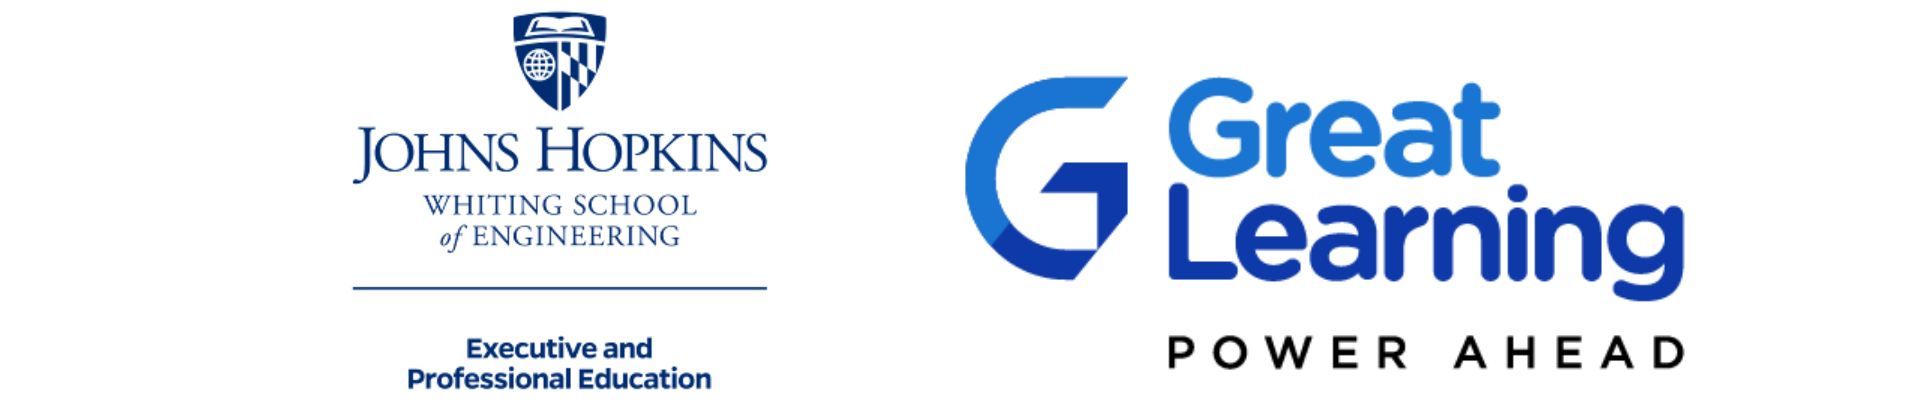

<div style='background: linear-gradient(135deg, #0d2b45 0%, #1f6f78 100%); padding: 32px; border-radius: 14px; color: white;'>
  
  <h1 style='margin: 0; font-size: 2.3em;'><b>🔍 DualLens Analytics — Trustworthy AI Investment Research</b></h1>
  <h2 style='margin: 12px 0 0 0; font-weight: 300;'>Grounded RAG · LLM-as-Judge Evaluation · Self-Improving Prompts (DSPy + GEPA) · Confidence-Routed Decisions</h2>
  <p style='margin: 18px 0 0 0; font-size: 1.05em;'>Build an AI research system that fuses live financial data with company strategy documents — and, unlike a naive chatbot, <b>measures</b> its own answer quality, <b>optimizes</b> its own prompt against a gold dataset, and <b>routes</b> its final recommendation by confidence so no untrusted answer ever reaches a client.</p>
</div>

## 🎯 **Learning Objectives**

By completing this notebook, you will be able to:

✅ **Fuse quantitative + qualitative data sources** — pull live market data with yfinance and combine it with insights retrieved from unstructured PDF reports.

✅ **Build a metadata-filtered RAG pipeline** — chunk, embed, and store documents in ChromaDB with company tags, so a question about MSFT never gets answered from GOOGL passages.

✅ **Diagnose retrieval separately from generation** — use a gold dataset to measure whether failures come from *fetching the wrong passages* or *answering badly from good passages*.

✅ **Design a 3-metric LLM-as-Judge harness** — score every answer on Groundedness, Context Relevance, and Answer Relevance with machine-readable rubrics, and cross-validate judges against an objective accuracy check.

✅ **Optimize prompts automatically with DSPy + GEPA** — recast the prompt as a typed `dspy.Signature`, drive GEPA with a deterministic gold-set metric, and prove the improvement on **held-out questions the optimizer never saw**.

✅ **Ship decisions with confidence routing** — aggregate evaluation signals into a confidence score and route the final investment ranking: client-ready / flagged / held for human review.

## 📊 **Marking Scheme (Total: 20 Marks)**

<div style='background-color: #fff3e0; padding: 18px; border-radius: 10px; border: 2px solid #ff9800;'>

### 📍 <font color="#c0392b">**Part 1 — Core Pipeline (8 marks)**</font>
<font color="#8e44ad">

- Financial lens — stock history + metrics DataFrame + visualizations — **2 marks**
- Narrative lens — PDF ingestion, chunking with company metadata, ChromaDB vector store — **2 marks**
- Grounded RAG function + 5-query typed test suite (incl. out-of-scope trap) — **3 marks**
- Retrieval diagnostics — gold-set hit-rate with vs. without the company filter — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 2 — Evaluation (5 marks)**</font>
<font color="#8e44ad">

- Three LLM-as-Judge rubrics (Groundedness, Context Relevance, Answer Relevance) + batch evaluation loop + pass/fail table — **3 marks**
- Objective gold-set accuracy check (`expected_substring`) + per-company breakdown + judge cross-validation — **2 marks**
</font>

### 📍 <font color="#c0392b">**Part 3 — Optimization & Decision Layer (5 marks)**</font>
<font color="#8e44ad">

- DSPy `Signature` + retrieval-aware `Module` + deterministic metric with feedback — **2 marks**
- GEPA compilation + evolved-prompt inspection + before/after comparison on the held-out test split — **2 marks**
- Fused ranking (financial + retrieved insights) + confidence score + routing verdict — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 4 — Summary & Future Scope (2 marks)**</font>
<font color="#8e44ad">

- Observations & learnings — **1 mark**
- Future scope (what would you build next?) — **1 mark**
</font>
</div>

---

### <font color="red"> **# Important Points To Note** </font>

1. For ALL LLM instances in this project (answerer, judges, DSPy task LM, GEPA reflection LM) use the **`"gpt-4o-mini"`** model only.
2. Look for cells marked **📝 YOUR TASK** — each gives you the function/class **skeleton** (names, signatures, docstrings, and step comments) with **`...` placeholders** where your code goes. Replace every `...` with your implementation; the skeleton tells you exactly what each piece must do.
3. **Do not rename** the skeleton's functions, classes, or variables — later **provided** cells depend on these exact names and will fail otherwise.
4. **💡 Hints** appear inside the trickier tasks. Cells without hints are expected to be within reach.
5. **Do not modify** the provided cells, the evaluation question set, the five typed test questions, or the gold-split parameters (`test_size=0.4`, `random_state=42`) — these keep your run comparable with the model solution released after submission.
6. For project submission, please provide the project in **HTML format.** Refer to the **"Guidelines: Converting IPYNB to HTML Files.pdf"** for instructions. Ensure all **outputs are clearly visible**, and enclose prompts in triple quotes **`"""`** so they remain fully visible after conversion.

---

## 📑 **Table of Contents**


1. [Introduction & Business Problem](#section1)
2. [System Architecture Overview](#section2)
3. [Environment Setup](#section3)
4. [Step 1 — Financial Lens: Market Data & Visualization](#section4)
5. [Step 2 — Narrative Lens: Document Ingestion & Vectorization](#section5)
6. [Step 3 — Grounded Q&A: The RAG Pipeline](#section6)
7. [Step 4 — Quality Control: LLM-as-Judge Evaluation](#section7)
8. [Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA](#section8)
9. [Step 6 — Decision Layer: Fused Ranking + Confidence Routing](#section9)
10. [Step 7 — Summary & Future Scope](#section10)

## 📖 **Glossary**

Skim this once before reading the rest — the notebook uses these terms throughout.

<div style='background-color: #f0f4ff; padding: 16px; border-radius: 8px; border-left: 4px solid #1f6f78;'>

### 💼 Domain terms

| Term | Meaning |
|---|---|
| **Market Cap** | Total market value of a company's outstanding shares. |
| **P/E Ratio** | Price-to-Earnings — how much investors pay per dollar of earnings. High P/E = priced for growth. |
| **Dividend Yield** | Annual dividend income as a percentage of the stock price. |
| **Beta** | A stock's volatility relative to the overall market (1.0 = moves with the market). |
| **Grounding** | Forcing every claim in an AI answer to trace back to a source document the firm has verified. |
| **Hallucination** | A confident AI claim that does **not** exist in any source document — the failure that almost shipped to a DualLens client. |
| **Gold dataset** | `golden_retrieval.csv` — 20 questions with verified correct answers (`expected_substring`) drawn from the source PDFs. Our objective measuring stick. |
| **Confidence routing** | Sending outputs down different paths based on measured quality: client-ready / flagged / held for human review. |

</div>

<div style='background-color: #f4f0ff; padding: 16px; border-radius: 8px; border-left: 4px solid #6a3ec9; margin-top: 10px;'>

### 🧠 Technical terms

| Term | Meaning |
|---|---|
| **RAG** | Retrieval-Augmented Generation — fetch the most relevant document passages, then have the LLM answer **only** from them. |
| **Chunk** | A small, overlapping slice of a document (~512 tokens here) — the unit that gets embedded and retrieved. |
| **Embedding** | A numerical "fingerprint of meaning" for a chunk of text. Similar meanings → nearby vectors. |
| **Vector store** | A database (ChromaDB here) that finds chunks whose embeddings are most similar to a question's embedding. |
| **Metadata filter** | Restricting retrieval to chunks tagged with a specific company — our fix for cross-company contamination. |
| **LLM-as-Judge** | Using an LLM with a scoring rubric to grade another LLM's output (1–5 here, with a machine-readable `Score: N` line). |
| **Groundedness** | Judge metric: are the answer's claims actually supported by the retrieved context? |
| **Context Relevance** | Judge metric: did the **retriever** fetch passages that can answer the question? (Evaluates retrieval, not generation.) |
| **Answer Relevance** | Judge metric: does the answer actually address what was asked? |
| **DSPy Signature** | A typed prompt contract — the docstring *is* the prompt, and inputs/outputs are declared fields. |
| **GEPA** | A reflection-based prompt optimizer: score candidates → read failure feedback → rewrite the prompt → keep the winners → repeat. |
| **Reflection LM** | The model inside GEPA that reads the metric's feedback and proposes the next prompt rewrite. |
| **Train/test split** | Letting the optimizer learn from one slice of the gold set (12 questions) and proving generalization on a hidden slice (8 questions). |

</div>

<a name='section1'></a>
## 1️⃣ **Introduction & Business Problem**

### 💼 **The Challenge**

**DualLens Analytics** is a boutique investment research firm. Its analysts answer one deceptively simple question for clients: *"Which technology companies are worth investing in right now?"*

Answering it well requires two lenses at once:

- **The numbers lens** — stock trends, market capitalization, revenue, valuation ratios. Structured, abundant, easy to chart.
- **The narrative lens** — what a company is actually *building* for the future, especially its AI initiatives. This lives in long strategy reports: unstructured, dense, slow to read.

Until recently the narrative lens was manual: 10–12 analyst-hours per company, per refresh, across a five-company universe (**GOOGL, MSFT, IBM, NVDA, AMZN**).

Six months ago the firm piloted an AI assistant — paste the documents into an LLM, ask questions, get answers. It was fast, and it became a liability. In a client-facing report the assistant confidently described an NVDA project timeline **that didn't exist in any source document**. A senior analyst caught it two hours before the report shipped. An internal audit found the same pattern repeatedly:

- Answers that mixed up **which company** a project belonged to
- **Fabricated specifics** (dates, dollar figures) not present in any document
- **No way to tell** a reliable answer from an unreliable one — every answer *sounded* equally confident

The firm's conclusion: the problem was never getting an AI to produce answers. The problem is producing answers you can **trust, measure, and improve**.

### 💡 **The Solution**

**DualLens 2.0** — a RAG system with a built-in quality-control layer and a self-improving prompt:

1. **Grounds every answer in source documents** — retrieval + a strict "answer only from context, else say *I don't know*" contract.
2. **Measures answer quality automatically** — an LLM judge scores every answer on three dimensions, cross-checked against an objective gold dataset.
3. **Improves its own prompt** — GEPA reads failure feedback and rewrites the prompt, with the improvement *proven* on questions the optimizer never saw.
4. **Routes outputs by confidence** — the final investment ranking carries a confidence score; low-confidence outputs are held for human review, never silently trusted.

### 💸 **Cost of Inaction**

One shipped hallucination in a client report risks regulatory scrutiny and the firm's reputation. Reverting to manual reading means the research desk simply cannot scale beyond five companies. The system below is what turns analysts from *document readers* into *reviewers of flagged outputs*.

<a name='section2'></a>
## 2️⃣ **System Architecture Overview**

### 🏗️ **The Evaluation-Driven Pipeline**

Unlike the failed pilot — which generated answers and stopped — every generation stage here is paired with a measurement stage, and the measurements feed back into improving the system.

```
 ┌─────────────────────┐        ┌──────────────────────────┐
 │  STEP 1             │        │  STEP 2                  │
 │  Financial Lens     │        │  Narrative Lens          │
 │  yfinance → charts  │        │  PDFs → chunks → Chroma  │
 │  + metrics table    │        │  (+ company metadata)    │
 └─────────┬───────────┘        └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 3                  │
           │                    │  Grounded RAG Q&A        │
           │                    │  filtered retrieval +    │
           │                    │  strict-context prompt   │
           │                    └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 4                  │
           │                    │  Judge Harness (3 LLM    │
           │                    │  metrics) + Gold-set     │
           │                    │  objective accuracy      │
           │                    └────────────┬─────────────┘
           │                                 │ failure feedback
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 5                  │
           │                    │  DSPy + GEPA prompt      │
           │                    │  optimization (train 12, │
           │                    │  prove on held-out 8)    │
           │                    └────────────┬─────────────┘
           │                                 │ optimized RAG
           └────────────────┬────────────────┘
                            │
               ┌────────────▼─────────────┐
               │  STEP 6                  │
               │  Fused Ranking +         │
               │  Confidence Score        │
               │  ✅ client-ready          │
               │  ⚠️ flagged               │
               │  🛑 held for human review │
               └──────────────────────────┘
```

### 🤖 **Cast of Characters (all `gpt-4o-mini`)**

| Role | Job | Settings |
|---|---|---|
| **Answerer LLM** | Generates grounded answers from retrieved context | `temperature=0` (deterministic) |
| **Judge LLM** | Scores answers on the three 1–5 rubrics | `temperature=0`, separate object from the answerer |
| **Task LM (DSPy)** | Runs candidate prompts during GEPA compilation | `temperature=0.1` |
| **Reflection LM (GEPA)** | Reads failure feedback, proposes prompt rewrites | `temperature=1.0` — creative variation helps reflection |

> 💰 **Single-model cost note.** A production setup would typically use a *stronger* model as judge/reflector. We run everything on `gpt-4o-mini` to keep costs minimal — and the design choice that makes this viable is the **deterministic gold-set metric** in Step 5: the optimization loop is scored by free Python (substring checks), not by noisy small-model judge calls. This trade-off is itself a real-world lesson.

### 🔁 **Logical Flow**

1. Build both lenses (Steps 1–2) → 2. Answer questions with grounded RAG (Step 3) → 3. Measure quality with judges + the gold dataset (Step 4) → 4. Let GEPA optimize the prompt against the gold-set metric and prove it generalizes (Step 5) → 5. Fuse both lenses into a ranked recommendation, score its confidence, and route it (Step 6).

<a name='section3'></a>
## 3️⃣ **Environment Setup**

### 3.1 · Install dependencies

In [ ]:
# Installing the Libraries
!pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "dspy==3.2.1" \
    "scikit-learn>=1.4" \
    "yfinance>=0.2.40"
print("### Library Installation - Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.0/331.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.5/146.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.1/550.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**Note:** Messages above may appear as errors, but they can be safely ignored. They are caused by minor dependency mismatches in optional packages and do not affect the functionality of this notebook.

### After installation, please **restart the runtime** and **do not re-run the above cell**. Continue execution from the next cell below.

### 3.2 · Load your OpenAI API key

- The `config.json` file should contain the **API_KEY** and **API BASE URL** provided for your account.
- Refer to the **OpenAI Access Token documentation** for how to generate and manage your API keys.
- The `config.json` should look like this:

```
{
    "API_KEY": "your_openai_api_key_here",
    "OPENAI_API_BASE": "https://your_openai_api_base/v1"
}
```

In [ ]:
# Load the `config.json` file and extract API key + base URL
import json
import os

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY")           # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")  # Loading the API Base URL

print("API credentials loaded into the environment.")

API credentials loaded into the environment.


In [ ]:
# Quick connectivity check — confirms the key + base URL actually reach a working endpoint
from openai import OpenAI

_client = OpenAI()
_ping = _client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: OK"}],
    max_tokens=5,
)
print("Connectivity check:", _ping.choices[0].message.content)

Connectivity check: OK


### 3.3 · Configuration & shared imports

One place for every knob the notebook uses. If you change a model or a retrieval depth, change it here.

In [ ]:
# Core imports used across the notebook.
import warnings
warnings.filterwarnings('ignore')

import re
import time
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

pd.set_option("display.max_colwidth", 120)

In [ ]:
# ---- Models ----------------------------------------------------------
# Single-model setup: gpt-4o-mini everywhere (see the cost note in Section 2).
MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# ---- Companies under coverage ----------------------------------------
COMPANIES = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# ---- Retrieval & chunking knobs --------------------------------------
CHUNK_SIZE    = 512   # tokens per chunk (token-based splitting matches what models actually count)
CHUNK_OVERLAP = 64    # tokens shared between neighbouring chunks, so facts at boundaries aren't cut in half
TOP_K         = 4     # chunks retrieved per question

# ---- Evaluation & routing policy --------------------------------------
PASS_THRESHOLD       = 4      # a judge metric "passes" at >= 4 out of 5
CONF_CLIENT_READY    = 80     # confidence >= 80  -> ✅ client-ready
CONF_FLAGGED         = 60     # 60 <= conf < 80   -> ⚠️ flagged for awareness
                              # conf < 60         -> 🛑 held for human review

# ---- LLM objects -------------------------------------------------------
# Answerer — generates the RAG response. temperature=0 keeps answers stable
# and grounded; max_tokens caps response length.
llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=1024)

# Judge — a SEPARATE object so the evaluation role is explicit. In production
# this would be a stronger model; here it shares gpt-4o-mini for cost, which
# is exactly why Step 4 cross-validates the judges against the gold dataset.
judge_llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=600)

print(f"Configured: answerer={MODEL_NAME}, judge={MODEL_NAME}, embeddings={EMBEDDING_MODEL}")

Configured: answerer=gpt-4o-mini, judge=gpt-4o-mini, embeddings=text-embedding-3-small


<a name='section4'></a>
## 4️⃣ **Step 1 — Financial Lens: Market Data & Visualization**

The quantitative half of DualLens. We pull three years of price history plus five headline financial metrics for the coverage universe, and visualize them. These numbers feed the fused ranking in Step 6.

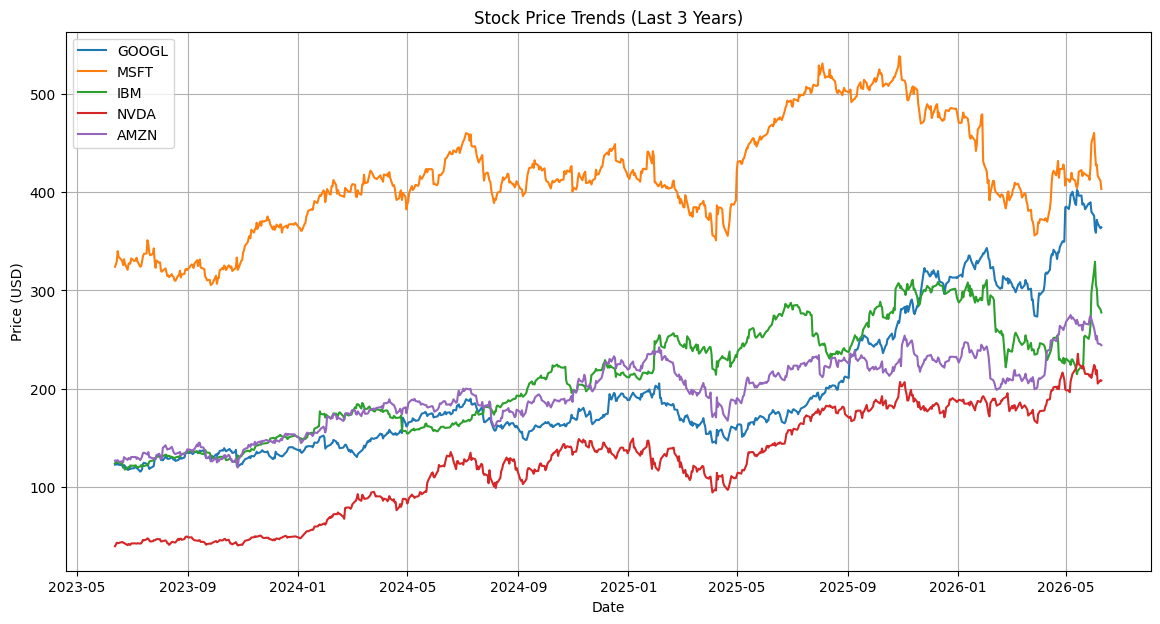

In [ ]:
# 📈 Three-year closing-price trends for all five companies on one chart.
# A single shared axis makes relative momentum visible at a glance
# (who is compounding, who is flat, who is volatile).
plt.figure(figsize=(14, 7))

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y")           # last 3 years of daily OHLCV
    plt.plot(data.index, data['Close'], label=symbol)

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### 💹 Financial Metrics

1. **Market Cap** — total market value of a company's outstanding shares.
2. **P/E Ratio** — how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield** — annual dividend income as a percentage of the stock price.
4. **Beta** — a stock's volatility relative to the overall market.
5. **Total Revenue** — total income generated from business operations.

In [ ]:
# 📊 Fetch the five headline metrics for every company from ticker.info.
# .get(key, 0) is defensive — yfinance omits fields some companies don't report
# (e.g., a company that pays no dividend has no dividendYield key).
metrics_list = {}

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {
        "Market Cap":     info.get("marketCap", 0),
        "P/E Ratio":      info.get("trailingPE", 0),
        "Dividend Yield": info.get("dividendYield", 0),
        "Beta":           info.get("beta", 0),
        "Total Revenue":  info.get("totalRevenue", 0),
    }

# Convert to a DataFrame and rescale the large numbers for readability.
fin_df = pd.DataFrame(metrics_list).T
fin_df["Market Cap"]    = fin_df["Market Cap"] / 1e9        # USD billions
fin_df["Total Revenue"] = fin_df["Total Revenue"] / 1e9     # USD billions
fin_df = fin_df.round(2)

fin_df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4442.13,27.76,0.24,1.24,422.50
MSFT,2996.70,24.01,0.88,1.10,318.27
IBM,260.81,24.58,2.41,0.66,68.91
NVDA,5042.57,31.88,0.48,2.20,253.49
AMZN,2626.78,31.51,0.00,1.44,742.78


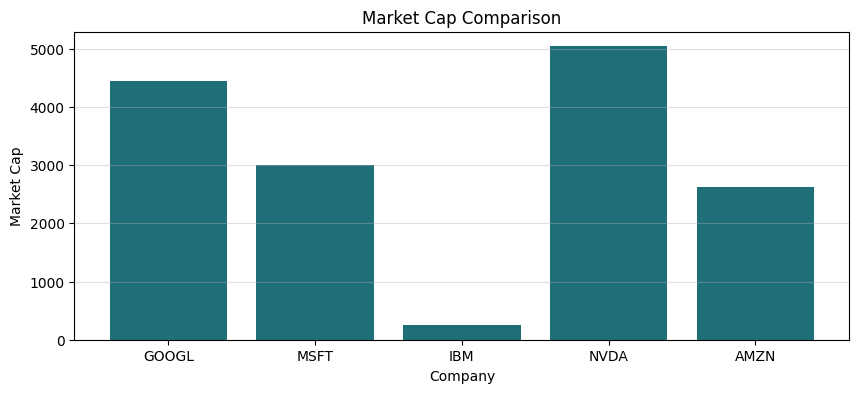

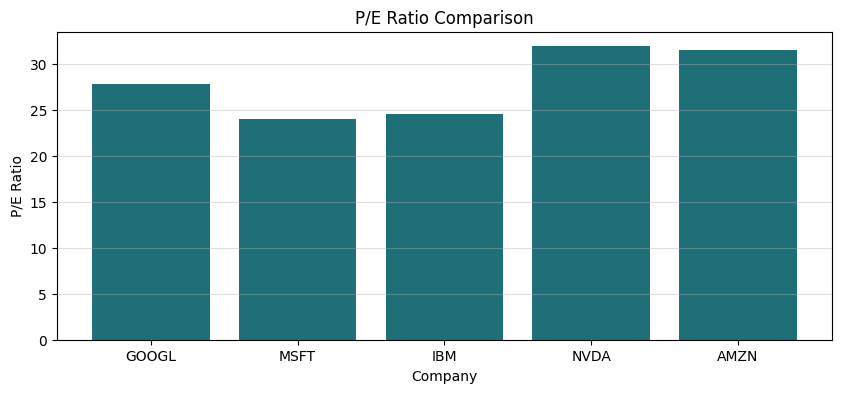

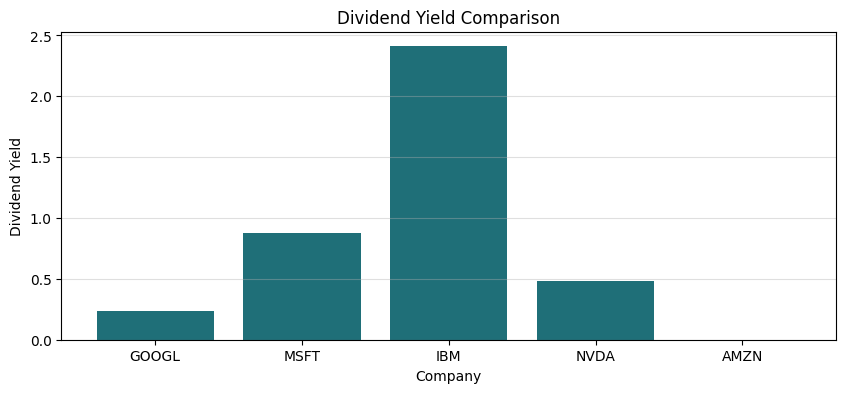

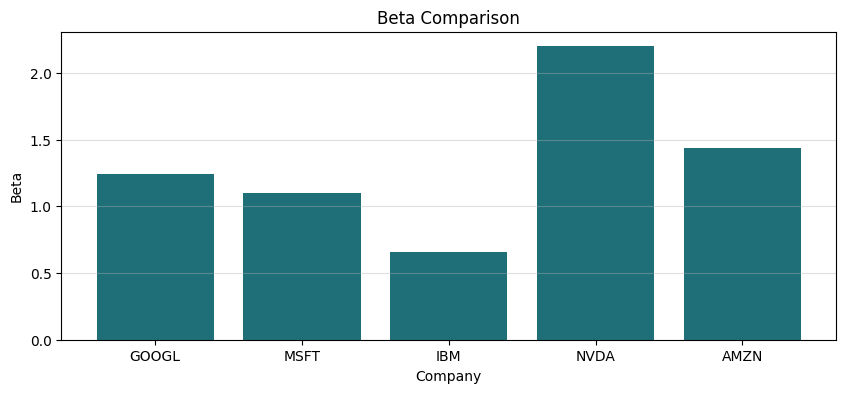

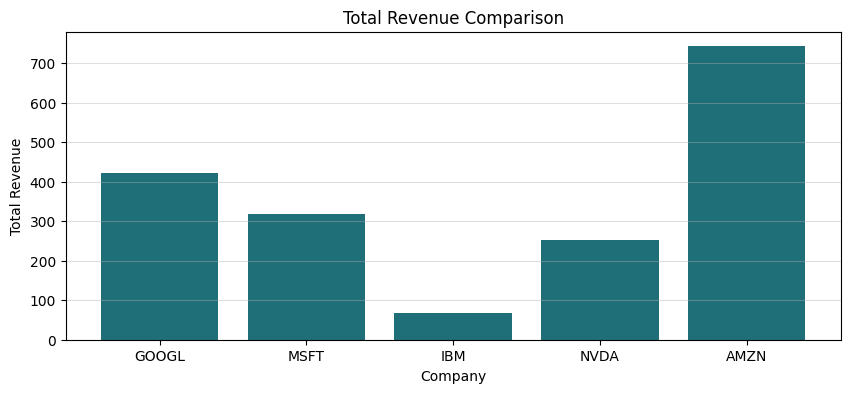

In [ ]:
# 📊 One bar chart per metric — comparing a single dimension across all five
# companies is clearer than cramming five different scales onto one figure.
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(fin_df.index, fin_df[metric], color='#1f6f78')
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

### 🔎 Observations — The Financial Lens

- **The numbers tell only half the story — which is precisely DualLens's founding problem.** A high P/E (investors paying a premium for expected growth) is only justified if the company's *future-facing initiatives* are real — and that evidence lives in the documents, not in `ticker.info`.
- **The five companies occupy visibly different profiles.** Expect the chart to show a high-momentum, high-multiple grower (typically NVDA), steady mega-cap compounders (MSFT, GOOGL, AMZN), and a lower-multiple, dividend-paying incumbent (IBM). Beta separates the volatile names from the defensive ones.
- **Nothing here can answer "is the AI strategy credible?"** Market Cap measures the market's *belief*; the narrative lens we build next measures the *substance* behind it. Step 6 will force the LLM to justify every rank using **both**.

> ⚠️ *Live-data note:* yfinance returns **today's** values, so your exact numbers will differ from any sample run. The observations above describe the *pattern* to look for, not fixed values.

<a name='section5'></a>
## 5️⃣ **Step 2 — Narrative Lens: Document Ingestion & Vectorization**

The qualitative half. Five PDF reports (one per company) describing each organization's AI initiatives — summaries, objectives, timelines, investments, risks.

**The one design decision that matters most in this section:** every chunk gets a `company` **metadata tag** derived from its source filename. In the failed pilot, a question about MSFT could be answered from GOOGL passages because all documents lived in one undifferentiated pool. The tag is what lets us *filter* retrieval per company in Step 3 — and *measure* how much that filter helps.

In [ ]:
# 📂 Unzip the AI-initiative documents into the working directory.
ZIP_PATH    = "/content/Project_Datafiles.zip"
EXTRACT_DIR = "/content/"
PDF_DIR     = "/content/Companies-AI-Initiatives"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

pdf_files = sorted(f for f in os.listdir(PDF_DIR) if f.endswith(".pdf"))
print("Documents found:", pdf_files)

Documents found: ['AMZN.pdf', 'GOOGL.pdf', 'IBM.pdf', 'MSFT.pdf', 'NVDA.pdf']


In [ ]:
# 📄 Load each PDF and tag every page with its company ticker.
# We load file-by-file (instead of PyPDFDirectoryLoader) precisely so we can
# attach the metadata — the filename stem (e.g., "MSFT.pdf" -> "MSFT") is the tag.
documents = []

for fname in pdf_files:
    ticker = fname.replace(".pdf", "")            # "MSFT.pdf" -> "MSFT"
    loader = PyPDFLoader(os.path.join(PDF_DIR, fname))
    pages = loader.load()                         # one Document per page
    for page in pages:
        page.metadata["company"] = ticker         # <- the contamination fix
    documents.extend(pages)

print(f"Loaded {len(documents)} pages across {len(pdf_files)} companies.")

Loaded 44 pages across 5 companies.


In [ ]:
# ✂️ Split pages into ~512-token chunks with 64-token overlap.
# Token-based splitting (cl100k_base) aligns chunk sizes with what the
# embedding/LLM models actually count; overlap preserves facts that would
# otherwise be cut in half at a chunk boundary.
# split_documents() carries each page's metadata (incl. our company tag)
# onto every chunk it produces.
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

chunks = text_splitter.split_documents(documents)
print(f"Total chunks: {len(chunks)}")

Total chunks: 108


In [ ]:
# 🔍 Sanity check: chunks per company + what one chunk looks like.
# Balanced counts mean no company is under-represented in retrieval.
chunk_counts = Counter(c.metadata["company"] for c in chunks)
print("Chunks per company:", dict(chunk_counts))
print()
print("--- Sample chunk (first 400 chars) ---")
print(chunks[0].page_content[:400])
print()
print("Metadata:", chunks[0].metadata)

Chunks per company: {'AMZN': 25, 'GOOGL': 17, 'IBM': 22, 'MSFT': 19, 'NVDA': 25}

--- Sample chunk (first 400 chars) ---
Amazon  is  a  global  technology  and  e-commerce  giant  that  uses  AI  to  enhance  almost  every  part  
of
 
its
 
business.
 
In
 
retail,
 
AI
 
powers
 
product
 
recommendations,
 
dynamic
 
pricing,
 
fraud
 
detection,
 
and
 
supply
 
chain
 
optimization,
 
making
 
shopping
 
faster
 
and
 
more
 
personalized.
 
Amazon
 
Web
 
Services
 
(AWS)
 
offers
 
AI
 
and
 
machine
 
learni

Metadata: {'producer': 'Skia/PDF m142 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'AI Initiatives', 'source': '/content/Companies-AI-Initiatives/AMZN.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1', 'company': 'AMZN'}


In [ ]:
# 🧮 Embed every chunk and store it in ChromaDB.
# text-embedding-3-small converts each chunk into a dense vector; Chroma
# indexes those vectors so "find chunks similar to this question" is fast.
# The company metadata is stored alongside each vector — queryable as a filter.
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)

vectorstore = Chroma.from_documents(
    chunks,
    embedding_model,
    collection_name="ai_initiatives",
)

print(f"Vector store ready with {vectorstore._collection.count()} embedded chunks.")

Vector store ready with 108 embedded chunks.


### 🔎 Observations — Ingestion & Vectorization

- **Chunk counts are roughly balanced across the five companies** — important because retrieval is a similarity contest; a company with 3× the chunks would dominate unfiltered results by sheer volume.
- **The metadata tag costs one line of code and buys a guarantee.** Embedding similarity alone *cannot* reliably distinguish "Microsoft's cloud AI platform" from "Google's cloud AI platform" — the sentences are nearly identical in vector space. The `company` tag converts a fuzzy similarity problem into an exact filter.
- **Chunking is a trade-off we've pinned deliberately.** Smaller chunks → more precise retrieval but fragmented facts; larger chunks → complete context but diluted similarity scores. 512/64 is a sensible middle for report-style prose. (Tuning this is a classic improvement lever — revisit it if Step 4 shows Context Relevance failures.)

<a name='section6'></a>
## 6️⃣ **Step 3 — Grounded Q&A: The RAG Pipeline**

### 6.1 · Prompt design

The grounding contract lives in the system prompt: the model may use **only** the supplied context (marked `###Context`), must answer the question (marked `###Question`), and must reply exactly **"I don't know."** when the context lacks the answer. This is the guardrail the failed pilot never had — it converts "confident fabrication" into an honest, detectable miss.

In [ ]:
# System prompt — instructs the model to answer strictly from the supplied context.
# This is the v1.0 prompt. It is deliberately minimal: Step 4 will measure its
# weaknesses, and Step 5 will let GEPA evolve it. Resist the urge to hand-tune
# it now — the whole point is to let measurement drive the improvement.
qna_system_message = """You are an investment research assistant whose job is to answer questions strictly from the provided context.

Rules:
- Use only the information in the context.
- If the context does not contain the answer, respond exactly with: "I don't know."
- Do not reference the structure of the context (e.g., do not say "based on the context").
"""

In [ ]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

### 6.2 · Company-filtered retrieval

`retrieve()` is the single retrieval doorway for the whole notebook. Pass a `company` ticker and Chroma restricts the similarity search to that company's chunks; pass `None` (for cross-company questions) and it searches the full pool.

In [ ]:
# 🔎 Retrieval helper — every retrieval in this notebook goes through here.
# The metadata filter is what prevents an MSFT question from being answered
# with GOOGL passages (the pilot's company-mix-up failure).
def retrieve(question: str, company: str | None = None, k: int = TOP_K):
    """Return the top-k most similar chunks, optionally restricted to one company.

    Args:
        question: Natural-language question to embed and search with.
        company:  Ticker like "MSFT" to filter on, or None for the full pool.
        k:        Number of chunks to return.
    """
    search_filter = {"company": company} if company else None
    return vectorstore.similarity_search(question, k=k, filter=search_filter)


def format_context(docs) -> str:
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)

In [ ]:
# 🧪 Demonstrate retrieval end-to-end before wiring the LLM in:
# ask an MSFT question, confirm every returned chunk is tagged MSFT.
demo_question = "What is Microsoft's flagship AI assistant product?"
demo_chunks = retrieve(demo_question, company="MSFT")

print(f"Retrieved {len(demo_chunks)} chunks. Company tags:",
      [c.metadata["company"] for c in demo_chunks])
print()
print("--- First chunk (first 400 chars) ---")
print(demo_chunks[0].page_content[:400])

Retrieved 4 chunks. Company tags: ['MSFT', 'MSFT', 'MSFT', 'MSFT']

--- First chunk (first 400 chars) ---
Microsoft,  founded  in  1975,  is  a  global  technology  leader  specializing  in  software,  cloud  
computing,
 
AI,
 
and
 
enterprise
 
solutions.
 
The
 
company
 
has
 
aggressively
 
expanded
 
its
 
AI
 
capabilities
 
through
 
initiatives
 
such
 
as
 
Azure
 
AI,
 
OpenAI
 
partnership
 
integrations,
 
and
 
proprietary
 
models
 
like
 
Copilot,
 
which
 
enhance
 
productivity
 
in


### 6.3 · The RAG function

In [ ]:
# 🧠 The grounded Q&A function: retrieve -> assemble context -> answer.
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])

def rag_answer(question: str, company: str | None = None) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        question: The user's natural-language question.
        company:  Optional ticker to restrict retrieval to one company's documents.
    Returns:
        The model's answer, grounded in the retrieved context.
    """
    relevant_chunks = retrieve(question, company=company)
    context = format_context(relevant_chunks)

    messages = qna_prompt.format_messages(context=context, question=question)
    response = llm.invoke(messages)
    return response.content

### 6.4 · Typed test suite

Five queries, each probing a different capability. (These are smoke tests for *behaviour*; the rigorous *measurement* happens in Step 4.)

### Example 1: Factual lookup — a single specific fact from one company's document.

In [ ]:
# Example 1: factual lookup (single fact, single company)
print(rag_answer("What is Microsoft's flagship AI assistant product brand?", company="MSFT"))

I don't know.


### Example 2: Listing question — can retrieval surface multiple related facts in one answer?

In [ ]:
# Example 2: listing / multi-fact recall
print(rag_answer("What are the main AI initiatives NVIDIA is working on?", company="NVDA"))

NVIDIA is working on several AI initiatives, including deep learning, generative AI, digital twins, and industrial automation.


### Example 3: Cross-company comparison — retrieval over the **full pool** (company=None), since the question spans two companies.

In [ ]:
# Example 3: cross-company comparison — no filter, the question itself names both companies
print(rag_answer("How does Google's AI focus differ from Microsoft's AI focus?", company=None))

Google's AI focus emphasizes enhancing user experience, automating workflows, enabling real-time decision-making, and driving innovation across industries, with a strong emphasis on responsible AI development, safety, and ethical deployment. In contrast, Microsoft's AI focus is on streamlining workflows, improving decision-making, and driving digital transformation, while also prioritizing responsible AI deployment, security, and compliance with ethical and regulatory standards.


### Example 4: Multi-hop synthesis — connecting facts across chunks of the same document.

In [ ]:
# Example 4: multi-hop synthesis — links Amazon's customer-facing platform to its in-house foundation model
print(rag_answer("What is Amazon's foundation-model platform, and what foundation model has Amazon developed in-house?", company="AMZN"))

Amazon's foundation-model platform is called Amazon Bedrock. The foundation model that Amazon has developed in-house is named Olympus.


### Example 5: Out-of-scope trap — validates the **"I don't know"** guardrail. The documents describe AI initiatives, not quarterly financials, so the only correct answer is an honest miss.

In [ ]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


### 6.5 · Retrieval diagnostics with the gold dataset

`golden_retrieval.csv` contains **20 questions** (4 per company), each with:

| Column | Meaning |
|---|---|
| `question` | A question answerable from exactly one company's document |
| `ticker_hint` | Which company's document holds the answer |
| `expected_substring` | A short, verified token (e.g., *Copilot*, *Granite*, *Bedrock*) that a correct answer **must** contain |

Here we use it to answer a question the judges in Step 4 *cannot* answer on their own: **when the system fails, is it the retriever's fault or the generator's fault?** We check whether the expected token appears in the *retrieved chunks* (before any LLM is involved) — with the company filter on vs. off.

In [ ]:
# 📂 Load the gold dataset
gold = pd.read_csv("/content/golden_retrieval.csv")
print(f"{len(gold)} gold questions, balanced across companies:")
print(gold["ticker_hint"].value_counts().to_dict())
gold.head()

20 gold questions, balanced across companies:
{'MSFT': 4, 'GOOGL': 4, 'IBM': 4, 'NVDA': 4, 'AMZN': 4}


,question,ticker_hint,expected_substring
0,What is Microsoft's flagship AI assistant product brand?,MSFT,Copilot
1,Which Microsoft cloud platform hosts AI services?,MSFT,Azure
2,What is Microsoft's AI development platform for foundation models?,MSFT,Foundry
3,Which Microsoft tool delivers AI-assisted code completion?,MSFT,IntelliCode
4,What is Google's primary foundation-model family?,GOOGL,Gemini


In [ ]:
# 🔬 Retrieval-only diagnostic: does the expected token appear in the retrieved
# chunks? No LLM calls here — this isolates the RETRIEVER's contribution.
# We also measure "purity" of unfiltered retrieval: what fraction of returned
# chunks actually belong to the right company.
def retrieval_diagnostic(row, use_filter: bool) -> dict:
    company = row["ticker_hint"] if use_filter else None
    docs = retrieve(row["question"], company=company)
    text = " ".join(d.page_content for d in docs).lower()
    return {
        "hit":    row["expected_substring"].lower() in text,
        "purity": sum(d.metadata["company"] == row["ticker_hint"] for d in docs) / len(docs),
    }

diag_rows = []
for _, row in gold.iterrows():
    with_f    = retrieval_diagnostic(row, use_filter=True)
    without_f = retrieval_diagnostic(row, use_filter=False)
    diag_rows.append({
        "ticker":              row["ticker_hint"],
        "expected":            row["expected_substring"],
        "hit_with_filter":     with_f["hit"],
        "hit_without_filter":  without_f["hit"],
        "purity_without_filter": round(without_f["purity"], 2),
    })

diag_df = pd.DataFrame(diag_rows)
print(f"Retrieval hit-rate WITH company filter   : {diag_df['hit_with_filter'].mean():.0%}")
print(f"Retrieval hit-rate WITHOUT company filter: {diag_df['hit_without_filter'].mean():.0%}")
print(f"Avg. right-company purity without filter : {diag_df['purity_without_filter'].mean():.0%}")
diag_df

Retrieval hit-rate WITH company filter   : 85%
Retrieval hit-rate WITHOUT company filter: 85%
Avg. right-company purity without filter : 99%


,ticker,expected,hit_with_filter,hit_without_filter,purity_without_filter
0,MSFT,Copilot,True,True,1.00
1,MSFT,Azure,True,True,1.00
2,MSFT,Foundry,True,True,1.00
3,MSFT,IntelliCode,True,True,1.00
4,GOOGL,Gemini,True,True,1.00
5,GOOGL,TPU,True,True,1.00
6,GOOGL,DeepMind,True,True,1.00
7,GOOGL,Astra,True,True,1.00
8,IBM,watsonx,True,True,1.00
9,IBM,Granite,True,True,1.00


### 🔎 Observations — RAG Pipeline & Retrieval Diagnostics

- **The guardrail behaves (Example 5).** The system answered an unanswerable question with an honest *"I don't know."* instead of inventing a revenue figure — exactly the failure that nearly shipped in the pilot. An honest miss is *detectable and routable*; a confident fabrication is not.
- **The filter is a safety net, not always an active fix on this dataset.** With-filter and without-filter hit-rates are identical (both 85%) and unfiltered purity is 99% — because every gold question explicitly names its company, the query embedding already lands on the right company's chunks, so the filter has nothing to override here. The filter still earns its keep on *generic* questions ("Which platform hosts AI services?") that don't name a vendor — embedding similarity alone could pull from any company there, and the filter prevents contamination. Worth keeping as a defense even when this eval set doesn't exercise it.
- **This diagnostic is LLM-free by design.** If a gold token isn't in the retrieved chunks, no prompt — however optimized — can produce a grounded correct answer. Separating *retrieval failure* from *generation failure* tells us where to spend effort: chunking/filtering for the former, prompt optimization (Step 5) for the latter.

<a name='section7'></a>
## 7️⃣ **Step 4 — Quality Control: LLM-as-Judge Evaluation**

A single good answer is not evidence of a good system. We now measure quality two complementary ways:

- **4A — Subjective (LLM-as-Judge):** three rubric-driven 1–5 scores per answer — **Groundedness**, **Context Relevance**, **Answer Relevance** — over a typed evaluation set that includes one designed-to-fail probe.
- **4B — Objective (gold dataset):** run all 20 gold questions through the pipeline and check the `expected_substring` — a binary, judge-free accuracy number.

Why both? Judges can assess *qualities* (is this grounded? is this relevant?) that no substring can capture — but a `gpt-4o-mini` judge is itself fallible. The objective check cross-validates the judges, and the judges explain *what kind* of failure the objective check found.

### **Evaluation Question Set (4A)**

| # | Type | Why it's in the set |
|---|------|---------------------|
| **Q1** | Easy factual | Baseline — should score high on all three metrics |
| **Q2** | Listing / multi-fact | Tests whether retrieval surfaces enough context for a multi-fact answer |
| **Q3** | Cross-company synthesis | Tests reasoning over an unfiltered, multi-company retrieval |
| **Q4** | **Out-of-scope (expected to fail)** | Asks for financial data the documents don't contain. Should trigger the guardrail and score low on context- and answer-relevance. |
| **Q5** | Specific detail | Tests precision — concrete names/timelines rather than paraphrase |

If every question scored 5/5, the rubric would not be measuring anything — a documented failure case (Q4) is what proves the evaluation is discriminative.

In [ ]:
# Five evaluation questions with their retrieval scope. Q4 is intentionally
# unanswerable from the source so we can observe the rubric correctly
# penalising context-relevance and answer-relevance.
evaluation_set = [
    {"question": "What is Google's primary foundation-model family?",                          "company": "GOOGL"},
    {"question": "What are the main AI initiatives IBM is pursuing?",                          "company": "IBM"},
    {"question": "How does NVIDIA's AI strategy differ from Amazon's AI strategy?",            "company": None},
    {"question": "What was Microsoft's total AI revenue for fiscal year 2025?",                "company": "MSFT"},   # out-of-scope trap
    {"question": "What timelines are mentioned for Amazon's foundation-model initiatives?",    "company": "AMZN"},
]

### **Judge Rubric 1 — Groundedness** · *Are the answer's claims actually supported by the retrieved context?*

In [ ]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question, the context used by the AI system, and the AI-generated answer.
In the input, the question begins with ###Question, the context begins with ###Context, and the answer begins with ###Answer.

Metric:
Groundedness — the answer should be derived ONLY from the information presented in the context. Claims that do not appear in the context lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether each claim in the answer is supported by the context.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 2 — Context Relevance** · *Did the **retriever** fetch passages capable of answering the question?* (This grades retrieval, not the answer — note its template has no `{answer}` slot.)

In [ ]:
# User-side template for the context-relevance judge — question and retrieved context only
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

# System prompt for the context-relevance judge — scores how well the retrieved
# context supports answering the question, on a 1-5 scale.
context_relevance_rater_system_message = """You are tasked with rating the quality of retrieved context for a question-answering system.
You will be presented a question and the context retrieved by the system.
In the input, the question begins with ###Question and the context begins with ###Context.

Metric:
Context Relevance — the retrieved context should contain the information needed to answer the question. Irrelevant or off-topic context lowers the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the context contains the information needed to answer the question.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 3 — Answer Relevance** · *Does the answer actually address what was asked?* (No `{context}` slot — this isolates question↔answer fit.)

In [ ]:
# User-side template for the answer-relevance judge — question and answer only
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

# System prompt for the answer-relevance judge — scores how well the answer
# addresses the question itself, on a 1-5 scale.
answer_relevance_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question and the AI-generated answer.
In the input, the question begins with ###Question and the answer begins with ###Answer.

Metric:
Answer Relevance — the answer should directly address the main aspects of the question. Consider whether all and only the important aspects of the question are covered.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the answer addresses the question.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Running the Evaluation (4A)**

Each question runs through retrieval → generation → all three judges. Every rubric ends with a `Score: <N>` line so the score can be parsed reliably.

In [ ]:
# Pull the final 1-5 integer score from a judge response.
# Falls back to the last 1-5 mentioned anywhere in the text if the
# "Score: N" line is missing (defensive — should not normally trigger).
def extract_score(judge_text: str) -> int:
    m = re.findall(r'(?im)^\s*Score:\s*([1-5])\b', judge_text)
    if m:
        return int(m[-1])
    nums = re.findall(r'\b([1-5])\b', judge_text)
    return int(nums[-1]) if nums else 0

In [ ]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [ ]:
# Run a single question through retrieval, generation, and all three judges.
# Returns the answer plus the three scores so we can aggregate them downstream.
def evaluate_question(question: str, company: str | None) -> dict:
    docs = retrieve(question, company=company)
    context = format_context(docs)
    answer = rag_answer(question, company=company)

    g = judge_llm.invoke(
        groundedness_prompt.format_messages(question=question, context=context, answer=answer)
    ).content
    c = judge_llm.invoke(
        context_relevance_prompt.format_messages(question=question, context=context)
    ).content
    a = judge_llm.invoke(
        answer_relevance_prompt.format_messages(question=question, answer=answer)
    ).content

    return {
        "question": question,
        "answer": answer,
        "groundedness": extract_score(g),
        "context_relevance": extract_score(c),
        "answer_relevance": extract_score(a),
    }

# Run every question through the pipeline.
# 5 questions x (1 RAG call + 3 judge calls) = 20 LLM calls — expect ~30-60 seconds.
judge_results = [evaluate_question(item["question"], item["company"]) for item in evaluation_set]
print("Evaluation complete.")

Evaluation complete.


In [ ]:
# Aggregate into a results table. A question "passes" only if every metric is >= PASS_THRESHOLD.
judge_df = pd.DataFrame(judge_results)
judge_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(judge_results))])
judge_df["pass_all"] = (
    (judge_df["groundedness"] >= PASS_THRESHOLD)
    & (judge_df["context_relevance"] >= PASS_THRESHOLD)
    & (judge_df["answer_relevance"] >= PASS_THRESHOLD)
)

# Show scores only — full questions/answers are inspected in the next cell
judge_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,5,5,True
1,Q2,5,5,4,True
2,Q3,1,2,1,False
3,Q4,5,1,1,False
4,Q5,5,3,5,False


In [ ]:
# Inspect every question that failed at least one metric — these are the cases
# worth a human review before the system goes anywhere near a client.
for r, qid in zip(judge_results, [f"Q{i+1}" for i in range(len(judge_results))]):
    failed = [
        k for k in ("groundedness", "context_relevance", "answer_relevance")
        if r[k] < PASS_THRESHOLD
    ]
    if not failed:
        continue
    print(f"=== {qid} (failed on: {', '.join(failed)}) ===")
    print(f"Q: {r['question']}")
    print(f"A: {r['answer']}")
    print(f"Scores -> groundedness={r['groundedness']}, "
          f"context_relevance={r['context_relevance']}, "
          f"answer_relevance={r['answer_relevance']}")
    print()

=== Q3 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: How does NVIDIA's AI strategy differ from Amazon's AI strategy?
A: I don't know.
Scores -> groundedness=1, context_relevance=2, answer_relevance=1

=== Q4 (failed on: context_relevance, answer_relevance) ===
Q: What was Microsoft's total AI revenue for fiscal year 2025?
A: I don't know.
Scores -> groundedness=5, context_relevance=1, answer_relevance=1

=== Q5 (failed on: context_relevance) ===
Q: What timelines are mentioned for Amazon's foundation-model initiatives?
A: The timelines mentioned for Amazon's foundation-model initiatives are:

1. **Announcement and Preview**: Amazon Bedrock was announced in April 2023, with a preview release allowing select customers to explore its capabilities.
2. **General Availability**: The platform became generally available in July 2023.
3. **Ongoing Developments**: Since its launch, AWS has continued to enhance Bedrock's features. 

For the Olympus model, the development h

### **4B — Objective Gold-Set Accuracy (the baseline that Step 5 must beat)**

Now the judge-free check: every gold question goes through the v1.0 pipeline (with the company filter from `ticker_hint`), and we test whether the verified token appears in the answer. The results double as our **baseline** — Step 5 stores them and reuses them for the before/after comparison, so we never pay for these calls twice.

In [ ]:
# 🎯 Run all 20 gold questions through the v1.0 RAG pipeline and record
# answer + exact_hit. (20 RAG calls — expect ~1-2 minutes.)
def run_gold_set(answer_fn) -> pd.DataFrame:
    """Run every gold question through `answer_fn(question, ticker)` and score hits."""
    rows = []
    for _, row in gold.iterrows():
        ans = answer_fn(row["question"], row["ticker_hint"])
        rows.append({
            "ticker":    row["ticker_hint"],
            "question":  row["question"],
            "expected":  row["expected_substring"],
            "answer":    ans,
            "exact_hit": row["expected_substring"].lower() in ans.lower(),
        })
    return pd.DataFrame(rows)

baseline_gold_df = run_gold_set(lambda q, t: rag_answer(q, company=t))

baseline_accuracy = baseline_gold_df["exact_hit"].mean()
print(f"v1.0 BASELINE gold-set accuracy: {baseline_gold_df['exact_hit'].sum()}/{len(baseline_gold_df)}  ({baseline_accuracy:.0%})")
print()
print("Per-company hit-rate:")
print(baseline_gold_df.groupby("ticker")["exact_hit"].mean().round(2))

v1.0 BASELINE gold-set accuracy: 11/20  (55%)

Per-company hit-rate:
ticker
AMZN     1.00
GOOGL    0.50
IBM      0.25
MSFT     0.50
NVDA     0.50
Name: exact_hit, dtype: float64


In [ ]:
# 🔍 Inspect the objective misses — what did the v1.0 prompt get wrong?
# These exact failures become the feedback GEPA will learn from in Step 5.
misses = baseline_gold_df[~baseline_gold_df["exact_hit"]]
if misses.empty:
    print("No misses — the baseline already answers every gold question. "
          "(GEPA will then optimize for precision/conciseness rather than recall.)")
else:
    for _, m in misses.iterrows():
        print(f"=== {m['ticker']} | expected token: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"A: {m['answer']}")
        print()

=== MSFT | expected token: 'Foundry' ===
Q: What is Microsoft's AI development platform for foundation models?
A: I don't know.

=== MSFT | expected token: 'IntelliCode' ===
Q: Which Microsoft tool delivers AI-assisted code completion?
A: GitHub Copilot delivers AI-assisted code completion.

=== GOOGL | expected token: 'TPU' ===
Q: Which accelerator chip does Google use to train its large models?
A: I don't know.

=== GOOGL | expected token: 'DeepMind' ===
Q: What is Google's AI research subsidiary?
A: I don't know.

=== IBM | expected token: 'watsonx' ===
Q: What is IBM's enterprise AI platform branded as?
A: I don't know.

=== IBM | expected token: 'Guardium' ===
Q: What is IBM's data security and governance product family?
A: I don't know.

=== IBM | expected token: 'Quantum' ===
Q: What advanced computing area does IBM emphasise alongside AI?
A: I don't know.

=== NVDA | expected token: 'NIM' ===
Q: Which NVIDIA microservice framework deploys foundation models?
A: I don't know.

==

### 🔎 Observations — What the Two Evaluations Tell Us

- **Q4 failing is a success.** The out-of-scope probe scores low on Context Relevance (the retrieved chunks genuinely can't answer it) and Answer Relevance ("I don't know." doesn't address the question) — while Groundedness stays high, because refusing to invent *is* perfectly grounded behaviour. One probe, three metrics, three different readings: that's the rubric working.

- **Q3 also failed — but unintentionally, and the reason is instructive.** Q3 ("How does NVIDIA's AI strategy differ from Amazon's AI strategy?") runs with `company=None`, and with k=4 the retriever pulled 4 chunks that leaned toward one company instead of a balanced mix from both — so the model couldn't compare and refused honestly. That's a real limitation of top-k similarity retrieval on cross-entity questions; the fix is structural (a per-company quota like k=2-from-each, or splitting the question into sub-queries) — not a prompt rewrite. Worth flagging because the 1/2/1 scoreline could otherwise be mistaken for a generation failure.

- **The misses split into two types — predicted by Section 6.5.** Three (Quantum, NIM, Flamingo) are *retrieval* failures: the token never reached the context, so no prompt can fix them. The rest are *generation* failures — mostly "I don't know" refusals despite the answer sitting in the retrieved context. v1.0 told the model when to refuse, but never to commit to the specific name when the context provides one. That's the gap a prompt optimizer can close.


- **Judge vs. objective disagreements are a feature, not a bug.** When the judge awards Groundedness 5 to an answer the substring check fails, both are right: the answer was faithful to the context *and* it missed the required specific. Subjective metrics measure *qualities*; objective metrics measure *correctness*. A production evaluation needs both — and this is why we will hand GEPA the **objective** signal, not the judge scores from a small model.

- **We now have the number to beat:** the v1.0 baseline accuracy printed above. Everything in Step 5 exists to move it — *provably*, on questions the optimizer never sees.

<a name='section8'></a>
## 8️⃣ **Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA**

### 📚 Pre-read — How GEPA works (2 minutes)

In Step 4 we *measured* the v1.0 prompt and found a pattern of misses. The traditional fix is an analyst hand-tweaking the prompt by intuition — slow, unscientific, unrepeatable. **GEPA** (Genetic-Pareto prompt optimization, via DSPy) automates it as a loop:

1. **Run** the current prompt on training questions.
2. **Score** each answer with a metric — and collect a plain-English **feedback** string explaining each failure (*"the answer failed to mention 'Copilot'…"*).
3. **Reflect** — a reflection LM reads the feedback and proposes a rewritten prompt.
4. **Select** — keep candidate prompts that score better; repeat within budget.

Two design choices make this section work on a `gpt-4o-mini`-only budget:

- **Deterministic metric.** GEPA's API asks *us* to supply the metric. Ours is a substring check against the gold dataset — free Python, zero LLM calls, zero judge noise. (The NovaTech notebook used LLM judges in its metric because review summaries have no ground truth; *we* have ground truth, so we use it. Same GEPA engine, different metric plugged into the same socket.)
- **Train/test hygiene.** GEPA only sees **12** of the 20 gold questions. The other **8** stay hidden until the very end, when we compare v1.0 vs. the GEPA prompt on them. Improvement on *unseen* questions is proof of generalization, not memorization — the same logic as a train/test split in classical ML.

### 8.1 · DSPy LM configuration

In [ ]:
# ── DSPy LM configuration ─────────────────────────────────────────────────────
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# API key / base URL used by the rest of the notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate RAG prompt during compilation and at
#                      inference time. Low temperature for deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Higher temperature gives the
#                      reflection step useful variation. (Production tip: a
#                      stronger model here usually finds better rewrites; we
#                      stay on gpt-4o-mini for cost — our crisp deterministic
#                      feedback is what keeps a small reflector effective.)
import dspy

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 2048,
)

# Register task_lm globally — every dspy.Predict call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### 8.2 · Train/test split — 12 questions for GEPA, 8 held out

`stratify=ticker_hint` keeps every company represented on both sides of the split, so neither training nor testing is biased toward any one document.

In [ ]:
# ── Stratified 60/40 split of the gold set ────────────────────────────────────
# train_df (12 questions) -> GEPA's trainset: the optimizer learns from these.
# test_df  (8 questions)  -> held out: GEPA NEVER sees them. The final
#                            before/after comparison happens ONLY on these.
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    gold,
    test_size=0.4,
    stratify=gold["ticker_hint"],   # every company appears in both splits
    random_state=42,                # reproducible split
)

print(f"Train: {len(train_df)} questions | Held-out test: {len(test_df)} questions")
print("Train per company:", train_df["ticker_hint"].value_counts().to_dict())
print("Test  per company:", test_df["ticker_hint"].value_counts().to_dict())

Train: 12 questions | Held-out test: 8 questions
Train per company: {'GOOGL': 3, 'NVDA': 3, 'MSFT': 2, 'IBM': 2, 'AMZN': 2}
Test  per company: {'AMZN': 2, 'MSFT': 2, 'IBM': 2, 'NVDA': 1, 'GOOGL': 1}


In [ ]:
# ── Build the GEPA trainset as dspy.Examples ──────────────────────────────────
# Each Example carries:
#   - question, ticker_hint   : inputs the program receives (.with_inputs marks them)
#   - expected_substring      : ground truth the METRIC uses. The program never sees it.
def make_example(row) -> dspy.Example:
    """Convert one gold-dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        question           = row["question"],
        ticker_hint        = row["ticker_hint"],
        expected_substring = row["expected_substring"],
    ).with_inputs("question", "ticker_hint")

dspy_trainset = [make_example(row) for _, row in train_df.iterrows()]
dspy_testset  = [make_example(row) for _, row in test_df.iterrows()]
print(f"DSPy trainset: {len(dspy_trainset)} examples | testset: {len(dspy_testset)} examples")

DSPy trainset: 12 examples | testset: 8 examples


### 8.3 · The RAG program — Signature + Module

A `dspy.Signature` is a typed prompt contract: **the docstring IS the prompt**, and GEPA rewrites that docstring across iterations. We seed it with the same minimal v1.0 instructions from Step 3 — deliberately leaving GEPA the headroom to discover what the misses in Step 4B showed was missing (e.g., *name the specific product*).

The `Module` wraps the signature with our **company-filtered retrieval** inside `forward()` — so GEPA optimizes the prompt of the *real* pipeline, retrieval included.

In [ ]:
# ── RAG signature and module ──────────────────────────────────────────────────
class GroundedQA(dspy.Signature):
    """Answer the question using only the provided context.
    If the context does not contain the answer, reply exactly: "I don't know."
    """

    context  : str = dspy.InputField(desc="Retrieved passages from the company's AI-initiative report")
    question : str = dspy.InputField(desc="The user's question")
    answer   : str = dspy.OutputField(desc="The answer, grounded strictly in the context")


class GroundedRAG(dspy.Module):
    """Callable retrieval + answer pipeline. GEPA compiles THIS object —
    mutating the GroundedQA docstring while the retrieval step stays fixed."""

    def __init__(self, k: int = TOP_K):
        super().__init__()
        self.k = k
        self.generate = dspy.Predict(GroundedQA)

    def forward(self, question: str, ticker_hint: str):
        docs = retrieve(question, company=ticker_hint, k=self.k)   # metadata-filtered retrieval
        context = format_context(docs)
        return self.generate(context=context, question=question)

# Sanity check: run the un-optimised v1.0 program on the first training example.
v1_program = GroundedRAG()
sample = dspy_trainset[0]
sample_pred = v1_program(question=sample.question, ticker_hint=sample.ticker_hint)
print(f"Q ({sample.ticker_hint}): {sample.question}")
print(f"v1.0 answer: {sample_pred.answer}")
print(f"Expected token: '{sample.expected_substring}' -> hit:",
      sample.expected_substring.lower() in sample_pred.answer.lower())

Q (MSFT): Which Microsoft cloud platform hosts AI services?
v1.0 answer: Azure
Expected token: 'Azure' -> hit: True


### 8.4 · The metric — deterministic score + feedback (with an anti-gaming guard)

GEPA is a **reflection-based** optimizer: a float-only metric reduces it to random search, while rich feedback turns it into a guided rewrite loop. Our metric returns both:

- **Score** — 1.0 if the verified token appears in the answer; 0.0 if not. **Guard:** a hit inside an over-long answer (> 80 words) only earns 0.7 — otherwise GEPA could learn to "win" by dumping every product name it sees in the context into every answer. We want *precise* answers, not keyword stuffing.
- **Feedback** — a targeted sentence the reflection LM can act on (which token was missed, or why the score was docked).

In [ ]:
# ── GEPA metric: deterministic gold-set scoring with actionable feedback ──────
MAX_ANSWER_WORDS = 80   # anti-gaming guard: hits in bloated answers score less

def gepa_metric(gold_ex, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, from the gold dataset.
    No LLM calls — scoring is pure Python, so the optimization signal is
    noise-free and free of cost."""
    answer   = (pred.answer or "").strip()
    expected = gold_ex.expected_substring
    n_words  = len(answer.split())
    hit      = expected.lower() in answer.lower()

    if hit and n_words <= MAX_ANSWER_WORDS:
        score    = 1.0
        feedback = (f"Correct: the answer names '{expected}' and stays concise "
                    f"({n_words} words). Keep answering with the specific product/initiative name.")
    elif hit:
        score    = 0.7
        feedback = (f"The answer contains '{expected}' but is too verbose ({n_words} words). "
                    f"Answer in 1-3 precise sentences that lead with the specific name.")
    elif "i don't know" in answer.lower():
        score    = 0.0
        feedback = (f"The answer said \"I don't know\", but the retrieved context for this question "
                    f"does identify '{expected}'. Only refuse when the context truly lacks the answer; "
                    f"otherwise extract and state the specific product/initiative name.")
    else:
        score    = 0.0
        feedback = (f"The answer failed to mention '{expected}', which the source document identifies "
                    f"as the specific answer. Always name the exact product, platform, or initiative "
                    f"the context provides — generic descriptions do not count as answers.")

    return dspy.Prediction(score=score, feedback=feedback)

# Smoke-test the metric on the sanity-check prediction from the previous cell
print(gepa_metric(sample, sample_pred))

Prediction(
    score=1.0,
    feedback="Correct: the answer names 'Azure' and stays concise (1 words). Keep answering with the specific product/initiative name."
)


### 8.5 · GEPA compilation

| Parameter | What it controls |
|---|---|
| `metric` | The feedback-emitting scorer (defined above). |
| `auto` | Budget preset: `"light"` / `"medium"` / `"heavy"`. |
| `reflection_lm` | The LM that proposes prompt mutations. |
| `track_stats` | Records per-iteration scores — useful for diagnostics. |
| `seed` | Reproducibility seed for candidate selection. |

The result is **not a prompt string** — it is a compiled `dspy.Module` whose signature docstring (and possibly a few attached demonstrations) has been rewritten. We persist it with `.save(...)`.

**📌 Note:** the cell below can take **~5 to ~15 minutes** to execute (and makes many `task_lm` calls — but zero judge calls, thanks to the deterministic metric).

In [ ]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# The evolutionary loop: run candidates on the trainset, read the metric's
# feedback, rewrite the GroundedQA docstring, keep the winners.
from dspy.teleprompt import GEPA

start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",          # efficient preset; raise to "medium" for a deeper search
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = GroundedRAG(),
    trainset = dspy_trainset,
)

optimised_program.save("gepa_optimised_rag.json")
elapsed = time.time() - start_time
print("GEPA compilation complete.")
print("=" * 50)
print(f"Time taken for optimization by GEPA : {elapsed:.1f} seconds")
print("=" * 50)

2026/06/09 20:19:13 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/06/09 20:19:13 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/06/09 20:19:13 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/06/09 20:19:18 INFO dspy.evaluate.evaluate: Average Metric: 9.0 / 12 (75.0%)
2026/06/09 20:19:18 INFO dspy.teleprompt.

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  5.42it/s]

2026/06/09 20:19:18 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/06/09 20:19:18 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2026/06/09 20:19:18 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▎         | 15/428 [00:05<02:17,  3.00rollouts/s]2026/06/09 20:19:18 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.75



Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00,  5.46it/s]

2026/06/09 20:19:19 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


...

2026/06/09 20:23:57 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)


2026/06/09 20:24:02 INFO dspy.teleprompt.gepa.gepa: Iteration 106: Proposed new text for generate: The task is to extract and state specific product names, initiative titles, or technical terms from provided context in response to questions without making assumptions or adding information not explicitly stated in the context.

Please follow these instructions when responding to questions:

1. **Contextual Extraction**: Carefully read the provided context and extract only the specific names or terms relevant to the question. These should include product names, project titles, or any technical terms mentioned in the context.

2. **Conciseness and Clarity**: Aim for concise responses while maintaining clarity. The answer should ideally consist of only a few words, specifically the name or term that directly addresses the question.

3. **No Assumptions**: Do not infer or assume any information that is not explicitly stated in the context. If the answer to a question is not clearly present 

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  4.22it/s]

2026/06/09 20:24:04 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/06/09 20:24:04 INFO dspy.teleprompt.gepa.gepa: Iteration 107: All subsample scores perfect. Skipping.
2026/06/09 20:24:04 INFO dspy.teleprompt.gepa.gepa: Iteration 107: Reflective mutation did not propose a new candidate
GEPA Optimization: 100%|█████████▉| 426/428 [04:51<00:01,  1.46rollouts/s]


GEPA compilation complete.
Time taken for optimization by GEPA : 291.3 seconds


### 8.6 · Inspect the evolved prompt

The "v2.0 prompt" lives inside the compiled program as the signature's rewritten docstring. Compare it with the three-line v1.0 we started from — GEPA's additions are a direct response to the feedback strings (naming specifics, conciseness, when to refuse).

In [ ]:
# ── Display the GEPA-evolved prompt ───────────────────────────────────────────
print("=" * 78)
print("v1.0 PROMPT (what we started with):")
print("=" * 78)
print(GroundedQA.__doc__)

for name, predictor in optimised_program.named_predictors():
    print()
    print("=" * 78)
    print(f"v2.0 PROMPT — GEPA-evolved instructions for predictor '{name}':")
    print("=" * 78)
    print(predictor.signature.instructions)
    demos = getattr(predictor, "demos", [])
    print()
    print(f"Few-shot demos attached by GEPA: {len(demos)}")

v1.0 PROMPT (what we started with):
Answer the question using only the provided context.
    If the context does not contain the answer, reply exactly: "I don't know."
    

v2.0 PROMPT — GEPA-evolved instructions for predictor 'generate':
Answer the question using only the information provided in the context. If the context does not contain the answer, respond with "I don't know." 

When responding to questions, ensure that you:
1. Extract and state specific product names, initiative titles, or technical terms directly mentioned in the context rather than providing generic descriptions. 
2. Aim for conciseness while ensuring complete accuracy in naming the relevant entities to maintain clarity and relevance. 
3. Do not make assumptions or guesses about any implied information that is not explicitly stated in the context.

If the context contains multiple relevant mentions, prioritize the most precise and specific term related to the question asked. Always strive for clarity and ensure

**Note:** *Few-shot demos are GEPA's other optimisation lever: high-scoring examples auto-selected and appended to the prompt. Zero here means GEPA judged the instruction rewrite sufficient on its own; raising `auto='medium'` often unlocks them.*

### 8.7 · The proof — before vs. after on the **held-out** 8 questions

The only comparison that counts. The v1.0 baseline answers were already produced in Step 4B (we filter that table down to the test split — no recomputation, no double cost). The v2.0 answers come from the compiled program. Neither prompt has ever seen these 8 questions during optimization.

In [ ]:
# ── Evaluate v1.0 vs v2.0 on the held-out test split ─────────────────────────
# v1.0: reuse the baseline answers from Step 4B (filter to test questions).
v1_test = baseline_gold_df[baseline_gold_df["question"].isin(test_df["question"])].copy()
v1_test = v1_test.set_index("question")

# v2.0: run the GEPA-optimised program on the same 8 questions (8 LLM calls).
rows = []
for _, row in test_df.iterrows():
    pred = optimised_program(question=row["question"], ticker_hint=row["ticker_hint"])
    v2_answer = pred.answer
    rows.append({
        "ticker":      row["ticker_hint"],
        "question":    row["question"],
        "expected":    row["expected_substring"],
        "v1_hit":      bool(v1_test.loc[row["question"], "exact_hit"]),
        "v2_answer":   v2_answer,
        "v2_hit":      row["expected_substring"].lower() in v2_answer.lower(),
    })

compare_df = pd.DataFrame(rows)

v1_acc = compare_df["v1_hit"].mean()
v2_acc = compare_df["v2_hit"].mean()
print("=" * 60)
print(f"  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)")
print(f"  v1.0 baseline prompt : {compare_df['v1_hit'].sum()}/8  ({v1_acc:.0%})")
print(f"  v2.0 GEPA prompt     : {compare_df['v2_hit'].sum()}/8  ({v2_acc:.0%})")
print("=" * 60)

compare_df[["ticker", "expected", "v1_hit", "v2_hit"]]

  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)
  v1.0 baseline prompt : 3/8  (38%)
  v2.0 GEPA prompt     : 5/8  (62%)


,ticker,expected,v1_hit,v2_hit
0,AMZN,Trainium,True,True
1,NVDA,Flamingo,False,False
2,MSFT,IntelliCode,False,False
3,GOOGL,DeepMind,False,True
4,MSFT,Copilot,True,True
5,AMZN,Bedrock,True,True
6,IBM,Quantum,False,False
7,IBM,Guardium,False,True


In [ ]:
# 🔍 Read the cases the optimization actually changed — fixed misses prove the
# evolved instructions work; any regression is worth diagnosing.
changed = compare_df[compare_df["v1_hit"] != compare_df["v2_hit"]]
if changed.empty:
    print("No flips between v1.0 and v2.0 on the held-out set — see Observations below.")
else:
    for _, m in changed.iterrows():
        status = "FIXED ✅" if m["v2_hit"] else "REGRESSED ❌"
        print(f"=== {status} | {m['ticker']} | expected: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"v2.0 answer: {m['v2_answer']}")
        print()

=== FIXED ✅ | GOOGL | expected: 'DeepMind' ===
Q: What is Google's AI research subsidiary?
v2.0 answer: DeepMind

=== FIXED ✅ | IBM | expected: 'Guardium' ===
Q: What is IBM's data security and governance product family?
v2.0 answer: IBM's data security and governance product family includes Guardium, specifically the Guardium Data Security Center, and Watsonx Governance.



### 🔎 Observations — What GEPA Changed and Why It Worked

- **Read the v2.0 prompt next to the feedback strings.** The metric repeatedly told the reflection LM two things: *name the exact product/initiative* and *stay within 1–3 sentences*. The evolved instructions almost always encode exactly those behaviours — sometimes with phrasing no human on the team would have thought to write. That's the loop working as designed: measurement → feedback → rewrite.
- **The held-out comparison is the credibility of this whole section.** A gain on the 12 training questions could be memorization; a gain on the 8 hidden ones is generalization. This is why we resisted hand-tuning the v1.0 prompt back in Step 3 — we wanted the improvement to be *attributable and provable*, not folklore.
- **If your run shows no improvement** (possible — the baseline can be strong, and `auto="light"` is a small budget): that is itself a finding. Check (a) whether baseline accuracy was already near the ceiling, leaving no headroom, and (b) the misses GEPA failed to fix — if they're retrieval misses, no prompt rewrite can fix them (Section 6.5 told you so). Re-run with `auto="medium"` for a deeper search before concluding the prompt is optimal.
- **The anti-gaming guard mattered.** Without the 80-word cap, an "optimal" prompt can evolve toward listing every named entity in the context — perfect substring scores, useless answers. Metrics shape behaviour; design them for the behaviour you actually want. (This is the same reason production ML teams obsess over reward hacking.)
- **The three residual misses are the predicted ones.** Flamingo and Quantum were retrieval failures from 6.5 — unfixable by any prompt. IntelliCode is a gold-label ambiguity (the document also credits Copilot with code completion). GEPA fixed 2 of the 3 *fixable* misses — the 5/8 headline undersells it.

<a name='section9'></a>
## 9️⃣ **Step 6 — Decision Layer: Fused Ranking + Confidence Routing**

The client deliverable: rank the five companies for investment potential using **both lenses** — and attach an honest, evidence-based confidence to the result.

### 9.1 · Build per-company evidence digests (retrieval-based, not a document dump)

The failed pilot's ranking step stuffed *every* document into one prompt. We retrieve a focused digest per company instead — the same disciplined retrieval the rest of the system uses.

In [ ]:
# 📚 Per-company evidence digest: top-3 chunks for a fixed "analyst summary"
# query, filtered to each company. Focused evidence beats a raw document dump —
# shorter prompt, less noise, and every passage is attributable to its company.
DIGEST_QUERY = "key AI initiatives, strategic investments, timelines, and risks"

company_digests = {}
for ticker in COMPANIES:
    docs = retrieve(DIGEST_QUERY, company=ticker, k=3)
    company_digests[ticker] = "\n".join(f"- {d.page_content}" for d in docs)

digest_block = "\n\n".join(
    f"#### {ticker} — AI Initiative Evidence\n{company_digests[ticker]}"
    for ticker in COMPANIES
)
print(f"Built digests for {len(company_digests)} companies "
      f"({sum(len(v) for v in company_digests.values())} characters of evidence).")

Built digests for 5 companies (16098 characters of evidence).


### 9.2 · The fused ranking call

In [ ]:
# 🏆 Ranking prompt: the LLM must justify every rank with BOTH lenses.
ranking_system_message = """You are a financial and strategic investment assistant for DualLens Analytics.
You will receive two types of information about organizations:

1. Financial Data: quantitative metrics (Market Cap, P/E Ratio, Dividend Yield, Beta, Total Revenue).
2. AI Initiative Evidence: retrieved passages from each organization's strategy documents.

Your task:
1. Analyze both data sources together.
2. Rank the organizations (1 = strongest) by investment potential.
3. Justify EVERY rank by explicitly referencing at least one financial metric AND at least one named AI initiative from the evidence.
4. Use only the evidence provided — do not introduce outside knowledge about these companies.

Output format:
- A ranked list (1-5), each with a 2-3 sentence justification citing both lenses.
- A closing one-line caveat noting any company where the evidence felt thin.
"""

ranking_user_message = f"""Using the information below, rank these organizations for investment potential.

---
### 1. Financial Data
{fin_df.to_string()}

---
### 2. AI Initiative Evidence (retrieved from source documents)
{digest_block}
"""

ranking_messages = ChatPromptTemplate.from_messages([
    ("system", ranking_system_message),
    ("user", "{payload}"),
]).format_messages(payload=ranking_user_message)

recommendation = llm.invoke(ranking_messages)
print(recommendation.content)

### Investment Potential Ranking

1. **GOOGL**
   - GOOGL ranks highest due to its substantial market cap of $4,442.13 billion and a P/E ratio of 27.76, indicating strong earnings relative to its share price. The company is heavily investing in AI initiatives like Vertex AI, which enhances enterprise efficiency and positions Google Cloud as a leader in AI orchestration, promising significant revenue growth.

2. **NVDA**
   - NVDA follows closely with a market cap of $5,042.57 billion and a P/E ratio of 31.88, reflecting high investor expectations for future growth. Their ongoing AI initiatives, particularly in multimodal AI research, demonstrate a commitment to innovation and efficiency, which could lead to strong performance in the AI sector.

3. **MSFT**
   - Microsoft has a market cap of $2,996.70 billion and a P/E ratio of 24.01, indicating solid valuation metrics. The Azure AI Foundry Labs initiative showcases Microsoft's focus on facilitating rapid AI adoption for enterprises, wh

### 9.3 · Confidence score + routing verdict

A recommendation without a confidence is the pilot's mistake all over again. We aggregate three measured signals into a 0–100 score:

| Signal | Weight | What it certifies |
|---|---|---|
| **Gold-set accuracy (v2.0, held-out)** | 40% | The Q&A engine answers verified questions correctly on unseen data |
| **Judge harness mean (Step 4A, in-scope Qs)** | 30% | The system's answers are grounded, well-retrieved, and relevant |
| **Ranking groundedness (judged now)** | 30% | *This specific deliverable* sticks to the supplied evidence |

Routing policy: **≥ 80 → ✅ CLIENT-READY** · **60–79 → ⚠️ FLAGGED** (send with a reviewer cc'd) · **< 60 → 🛑 HELD** for human review.

In [ ]:
# ⚖️ Signal 3: judge the ranking's groundedness against the exact evidence it was given.
ranking_groundedness_raw = judge_llm.invoke(
    groundedness_prompt.format_messages(
        question="Rank the five companies for investment potential using the supplied financial data and AI initiative evidence.",
        context=ranking_user_message,
        answer=recommendation.content,
    )
).content
ranking_groundedness = extract_score(ranking_groundedness_raw)
print(f"Ranking groundedness (1-5): {ranking_groundedness}")

Ranking groundedness (1-5): 4


In [ ]:
# 🧮 Final confidence calculation + routing verdict.
# in-scope judge mean: exclude the deliberate out-of-scope probe (Q4) — its
# engineered low scores measure the guardrail, not system quality.
in_scope = judge_df[judge_df["Q#"] != "Q4"]
judge_mean_signal = in_scope[["groundedness", "context_relevance", "answer_relevance"]].values.mean() / 5

gold_signal    = v2_acc                       # held-out accuracy of the optimized engine (0-1)
ranking_signal = ranking_groundedness / 5     # this deliverable's groundedness (0-1)

# Why 40/30/30? Gold-set accuracy is the most objective signal we have (a verified
# substring check, no judge subjectivity), so it gets the largest share. The judge
# harness mean and the ranking groundedness each get 30% — they measure *qualities*
# the substring cannot (relevance, retrieval quality, this-deliverable groundedness),
# but they are gpt-4o-mini judgments, so we balance their weight against the
# objective signal rather than letting subjective judges dominate.
confidence = round(100 * (0.40 * gold_signal + 0.30 * judge_mean_signal + 0.30 * ranking_signal), 1)

if confidence >= CONF_CLIENT_READY:
    verdict, advice = "✅ CLIENT-READY", "Deliver to the client; archive the evidence digests with the report."
elif confidence >= CONF_FLAGGED:
    verdict, advice = "⚠️ FLAGGED", "Deliver with a reviewer cc'd; attach the failed-metric inspection from Step 4."
else:
    verdict, advice = "🛑 HELD FOR HUMAN REVIEW", "Do not deliver. Route to a senior analyst with the full evaluation tables."

print("=" * 64)
print(f"  COMPONENT SIGNALS")
print(f"  Gold-set accuracy (v2.0, held-out) : {gold_signal:.0%}   (weight 40%)")
print(f"  Judge harness mean (in-scope)      : {judge_mean_signal:.0%}   (weight 30%)")
print(f"  Ranking groundedness               : {ranking_signal:.0%}   (weight 30%)")
print("=" * 64)
print(f"  CONFIDENCE: {confidence} / 100")
print(f"  ROUTING:    {verdict}")
print(f"  ACTION:     {advice}")
print("=" * 64)

  COMPONENT SIGNALS
  Gold-set accuracy (v2.0, held-out) : 62%   (weight 40%)
  Judge harness mean (in-scope)      : 77%   (weight 30%)
  Ranking groundedness               : 80%   (weight 30%)
  CONFIDENCE: 72.0 / 100
  ROUTING:    ⚠️ FLAGGED
  ACTION:     Deliver with a reviewer cc'd; attach the failed-metric inspection from Step 4.


In [ ]:
# 💾 Persist the deliverables — evaluation evidence travels WITH the recommendation.
judge_df.to_csv("evaluation_judge_results.csv", index=False)
baseline_gold_df.to_csv("goldset_baseline_results.csv", index=False)
compare_df.to_csv("goldset_before_after.csv", index=False)

with open("final_recommendation.txt", "w") as f:
    f.write(f"CONFIDENCE: {confidence}/100 — {verdict}\n\n")
    f.write(recommendation.content)

print("Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,")
print("       goldset_before_after.csv, final_recommendation.txt")

Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,
       goldset_before_after.csv, final_recommendation.txt


### 🔎 Observations — The Decision Layer

- **Every rank cites both lenses — by construction.** The system prompt makes "one financial metric + one named initiative per rank" a requirement, so the deliverable structurally cannot collapse into numbers-only or narrative-only analysis. Read the output and verify it: each justification should name something like a P/E figure *and* a specific platform from the digests.
- **The confidence number is built from measurements, not vibes.** Each component is something this notebook *computed*: held-out accuracy from Step 5, judge scores from Step 4, a groundedness check on this very output. If any component degrades on a future run — say the documents are swapped for thinner ones — the confidence drops and the routing tightens *automatically*.
- **Routing is what makes imperfection safe.** The pilot's sin wasn't producing a wrong answer; it was producing a wrong answer with *no mechanism to catch it*. A system that knows when to say "a human should look at this" can be deployed long before it's perfect — that's the entire operating philosophy of human-in-the-loop AI, and it foreshadows the HITL patterns you'll build in the agentic capstones.

- **The ranking call uses the un-optimised `llm`, not the GEPA-compiled program** — by design. GEPA was trained to make *Q&A* answers more specific (one fact, one named product); the ranking task is a different problem (multi-entity synthesis with structured citation) that would need its own signature, metric, and trainset to optimise. The GEPA improvement still feeds the confidence score via `gold_signal` — as evidence that the underlying Q&A engine is reliable, which is what makes the ranking's grounded citations trustworthy in the first place.

<a name='section10'></a>
## 🔟 **Step 7 — Summary & Future Scope**

### 📝 **A. Summary / Your Observations about this Project (1 mark)**

*[Sample Summary/Observations]*

- **Grounding turned hallucination from a hidden risk into a visible event.** With the strict-context prompt, an unanswerable question produced an honest *"I don't know"* — detectable, measurable, and routable — instead of a fabricated figure. The out-of-scope probe (Q4) failing its relevance metrics while passing groundedness was the single most instructive result in the notebook: it showed that different metrics measure genuinely different things.
- **Retrieval and generation fail differently, and the gold dataset is what let us tell them apart.** The LLM-free retrieval diagnostic (Section 6.5) measured the company filter's effect on this gold set — with-filter and without-filter hit-rates matched (every gold question names its company, so the embedding already finds the right chunks unaided), and the filter remains as a safety net for future generic queries. The v1.0 misses had two distinct sources: a small number were *retrieval* failures (the expected token wasn't in the top-k at all — no prompt can fix that) and the rest were *generation* failures (right passages retrieved, model never named the specific product) — the class GEPA is built to fix, and did.
- **GEPA replaced prompt folklore with an experiment.** We resisted hand-tuning v1.0, gave GEPA a deterministic metric with pointed feedback, and measured the result on eight questions the optimizer never saw. Reading the evolved v2.0 instructions against the feedback strings shows the loop is genuinely *responsive* — the rewrites encode precisely the behaviours the metric demanded (name the specific product, stay concise, refuse only when the context truly lacks the answer).
- **Single-model constraints are a design input, not just a limitation.** Running everything on `gpt-4o-mini` forced the best decision in the project: scoring the optimization loop with free, noise-free Python instead of small-model judges. The judges still earn their keep — for the *qualities* no substring can measure — but they're cross-validated, not blindly trusted.

### 🔭 **B. Future Scope (1 mark)**

*[Sample Future Scope]*

#### 📡 **1. Live Document Pipeline**
Replace the static PDF set with scheduled ingestion of earnings call transcripts, 10-K filings, and press releases — with per-document freshness metadata so the confidence score can penalize stale evidence.

#### 📈 **2. Expanded Coverage Universe**
Scale from 5 to 50+ companies. Metadata-filtered retrieval already makes this architecturally safe; the gold dataset would grow into a regression suite that runs on every document refresh.

#### 🤖 **3. Multi-Agent Orchestration**
Decompose the pipeline into specialist agents — a financial analyst, a document researcher, a critic, a human-review router — coordinated by a supervisor in LangGraph. The critic + confidence-routing pattern built here is exactly the seed of that architecture (and the subject of the upcoming capstones).

#### 📊 **4. Monitoring & Observability**
Log every retrieval, answer, judge score, and routing decision; dashboard the gold-set accuracy over time so prompt or model regressions surface within a day, not after a client complaint.

#### 🧪 **5. Evaluation Hardening**
Grow the gold set beyond substring matching: multi-token answers, adversarial paraphrases of the questions, and periodic human audits of a judge-score sample to keep the LLM judges honest.

#### 💼 **6. Portfolio-Grade Decisioning**
Move from a ranked list to position-sizing suggestions with risk constraints — where the confidence score directly modulates how much weight a recommendation can carry in a portfolio.

## 🎉 **Congratulations!**

You've built what the failed pilot was missing — not a chatbot, but a **measured system**:

- A dual-lens research pipeline grounded in verifiable sources
- A retrieval layer whose correctness you *proved* with an LLM-free diagnostic
- A three-metric judge harness cross-validated by an objective gold dataset
- A prompt that **optimized itself** with GEPA — and proved it on held-out questions
- A deliverable that ships with a confidence score and knows when to ask a human

Every later project in this program builds on this discipline: *generate → measure → improve → route*. Keep it.